# Strings — Physical Modelling, from First Principles
Companion notebook to **`PROJECT_GUIDE.md`**, **`string_analysis.py`**, and **`string_synth.py`**.

This walks the string milestone ladder (S0 → S7), proving each step **empirically**: pluck/impulse-test the resonator, look at where the modes actually land, then listen. Everything is built on the same waveguide machinery as the woodwind and brass tracks — two travelling-wave delay lines, a frequency-dependent loss filter, fractional-delay tuning — re-wired for a fixed–fixed, body-radiated, variously-excited string.

Two layers, kept separate on purpose (same split as `brass.py`):
- **Analysis** (`string_analysis.py`) — *why* it works: spectra, pitch, partial and inharmonicity measurement, decay slopes. Pure diagnostics.
- **Synthesis** (`string_synth.py`) — *making it playable*: plucked, bowed, hammered, coupled models. Pure DSP — returns numpy arrays, never touches a file or sound card. WAV writing lives in `render_assets.py`; inline playback below uses `IPython.display.Audio` (§5).

| # | Milestone | Key physics | Wind/brass analogue |
|---|-----------|-------------|---------------------|
| **S0** | Karplus–Strong | minimal waveguide — *is* the plucked string | = M0, re-framed |
| **S1** | Two-delay-line string | fixed–fixed ($r=-1$), all harmonics, Mersenne pitch, pluck comb | M1 |
| **S2** | Frequency-dependent loss | loss-as-filter with explicit state | M2 |
| **S3** | Stiffness → dispersion | **all-pass** in the loop → stretched partials | replaces bore sections (M3) |
| **S4** | Bowed string | stick–slip friction ↔ string feedback (MSW); Helmholtz *emerges* | the reed (M4) |
| **S5** | Bridge + body | commuted synthesis | radiation + bell (M5) |
| **S6** | Polarizations + unisons | two-stage decay, beating | realism layer |
| **S7** | Piano hammer | nonlinear felt contact; velocity → brightness | new excitation class |

## Setup

Import both engines. `A` is the analysis/diagnostics layer, `S` the synthesis models; the DSP nodes live in `A` and are shared. `Audio` gives the inline players.

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Audio, display
import string_analysis as A
import string_synth as S
from string_analysis import FS
np.random.seed(0)
norm = lambda y: y / (np.max(np.abs(y)) + 1e-12)
print("engines loaded — FS =", FS)

engines loaded — FS = 44100


## S0 — Karplus–Strong, repositioned

Wind M0 called this a plumbing check. For strings it **is** the instrument: the noise burst is the broadband initial condition of a pluck, the loop is the string's round trip, the two-point averager is frequency-dependent loss (§6.5). Everything after this is Karplus–Strong with the physics made explicit.

The printed tuning error is the point — integer-$N$ delay quantises pitch to a grid far coarser than the frequency JND (§3.4), which is what S1 fixes with fractional delay.

In [2]:
y_s0 = S.karplus_strong(220.0)
print(f"target f0 = {FS/round(FS/220.0):7.2f} Hz   measured = {A.estimate_f0(y_s0):7.2f} Hz")
print("(integer-N tuning error is exactly why S1 adds fractional delay)")
display(Audio(y_s0, rate=int(FS)))

target f0 =  220.50 Hz   measured =  221.05 Hz
(integer-N tuning error is exactly why S1 adds fractional delay)


## S1 — Two-delay-line string, fixed–fixed

Transverse waves obey the same 1-D wave equation as tube pressure — d'Alembert again: a right- and a left-going half interacting only at boundaries (§2.1). Three facts are string-specific.

**Boundaries.** Both ends are *fixed* (nut, bridge). A rigid termination is a displacement node, so the reflected wave cancels the incident one: $r=-1$ at **both** ends. Two inversions per round trip cancel, so the wave repeats every round trip:

$$f_n=\frac{n\,c}{2L}\quad\text{— fundamental }\tfrac{c}{2L},\ \textbf{all harmonics.}$$

No clarinet-style odd-only case exists for an ideal string — the closed–open asymmetry has no analogue.

**Pitch.** $c=\sqrt{T/\mu}$, so $f_0=\tfrac{1}{2L}\sqrt{T/\mu}$ (Mersenne). Three physical knobs feed the delay: tension (peg), density (gauge), length (fret).

**Excitation.** A pluck is an **initial condition**: a triangular displacement split 50/50 onto the two waves. Amplitudes go as $\sin(n\pi\beta)/n^2$ for a pluck at $\beta L$, so plucking at $L/5$ nulls harmonics 5, 10, 15… — "bright near the bridge, mellow over the soundhole."

*Gate:* $f_0$ within a cent; all harmonics with $f_n/(nf_0)=1$; harmonics 5 & 10 notched.

target f0 = 220.00 Hz   measured = 220.00 Hz (+0.0 cents)
n    f_n (Hz)   f_n/(n·f0)   level (dB)
 1     220.00     1.0000        0.0
 2     440.00     1.0000       -3.3
 3     660.00     1.0000       -9.9
 4     880.00     1.0000      -21.0
 5    1100.00     1.0000      -38.8
 6    1320.00     1.0000      -36.8
 7    1540.00     1.0000      -49.7
 8    1760.00     1.0000      -39.8
 9    1980.00     1.0000      -43.7
10    2200.00     1.0000      -66.6
11    2420.01     1.0000      -53.1
12    2640.01     1.0000      -55.3
pluck at L/5 → harmonics 5,10 notched (≥12 dB under h4/h8): CONFIRMED


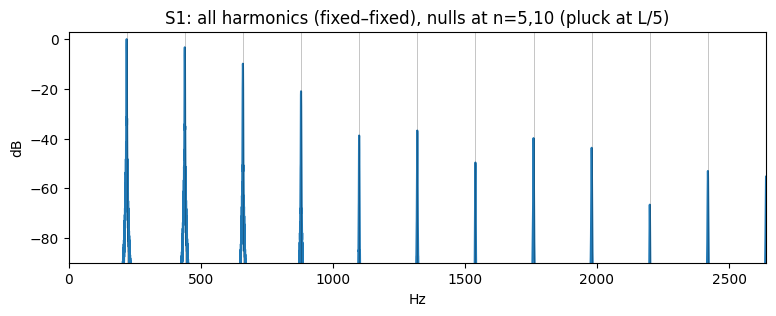

In [3]:
y_s1 = S.pluck_string(220.0, pluck_frac=0.20, loss_scalar=0.998)
f_meas, tbl = A.harmonic_table(y_s1, 220.0, nmax=12)
print(f"target f0 = 220.00 Hz   measured = {f_meas:.2f} Hz "
      f"({1200*np.log2(f_meas/220.0):+.1f} cents)")
print("n    f_n (Hz)   f_n/(n·f0)   level (dB)")
for n in sorted(tbl):
    fn, ratio, lvl = tbl[n]
    print(f"{n:2d}  {fn:9.2f}   {ratio:8.4f}    {lvl:7.1f}")
ok5 = 5 in tbl and 4 in tbl and tbl[5][2] < tbl[4][2] - 12
ok10 = 10 in tbl and 8 in tbl and tbl[10][2] < tbl[8][2] - 12
print(f"pluck at L/5 → harmonics 5,10 notched (≥12 dB under h4/h8): "
      f"{'CONFIRMED' if ok5 and ok10 else 'check spectrum'}")

plt.figure(figsize=(9, 3))
f, db = A.spectrum_db(y_s1); plt.plot(f, db)
plt.xlim(0, 12 * 220); plt.ylim(-90, 3)
for n in range(1, 13): plt.axvline(n * 220, color='k', lw=0.4, alpha=0.4)
plt.title("S1: all harmonics (fixed–fixed), nulls at n=5,10 (pluck at L/5)")
plt.xlabel("Hz"); plt.ylabel("dB"); plt.show()
display(Audio(y_s1, rate=int(FS)))

## S2 — Frequency-dependent loss

Transfers verbatim from M2 (§2.4): losses rise with frequency, so the honest boundary loss is a **low-pass**, not a scalar — the bright attack relaxing into a warm hum. New wrinkle: the filter's *phase delay* must be subtracted from the loop budget (`phase_delay`) or the note lands flat.

*Gate:* pitch on target after compensation; the >2.5 kHz band decays markedly faster than the <900 Hz band.

In [4]:
y_s2 = S.pluck_string(220.0, fc=5500, gain=0.999, dur_s=2.0)
print(f"measured f0 = {A.estimate_f0(y_s2):.2f} Hz")
d_lo, d_hi = A.band_decay_db(y_s2)
print(f"decay over 2 s:  <900 Hz: {d_lo:6.1f} dB    >2.5 kHz: {d_hi:6.1f} dB")
print("high band decays faster → loss-as-filter CONFIRMED"
      if d_hi < d_lo - 6 else "WARNING: bands decaying alike")
display(Audio(y_s2, rate=int(FS)))

measured f0 = 220.01 Hz
decay over 2 s:  <900 Hz:   -7.7 dB    >2.5 kHz:  -16.4 dB
high band decays faster → loss-as-filter CONFIRMED


## S3 — Bending stiffness → dispersion → inharmonicity

**The** string-specific milestone; it replaces the wind track's bore sections. A real string resists *bending*, so high partials travel **faster** and land sharp:

$$f_n\approx n f_0\sqrt{1+Bn^2},\qquad B=\frac{\pi^3 E d^4}{64L^2T}\ \ (\text{piano wire: }10^{-4}\dots10^{-2}).$$

This is why pianos get stretched-octave tuning. In the waveguide, dispersion is an **all-pass** in the loop — unit magnitude everywhere (passivity intact, §6.3) but frequency-dependent *delay*; with $a<0$, high frequencies see less delay. Tidy symmetry: loss shapes $|H|$, dispersion shapes $\angle H$.

**Empirical lesson.** A weak chain ($a=-0.35,M=16$) gave an inaudible $B\approx10^{-5}$ — partials below ~1.5 kHz sit on the nearly-linear part of a first-order all-pass phase. $a=-0.6,M=40$ was chosen by solving $f\,D(f)=n f_s$ offline, predicting $B\approx2.4\times10^{-4}$, and the synthesized string measures the same.

**Honest limitation:** identical first-order all-passes give the right *qualitative* stretch, not an exact $\sqrt{1+Bn^2}$; a measured $B$ needs designed higher-order all-passes (Smith, PASP, "stiff strings").

*Gate:* stretch grows monotonically with $n$; fitted $B$ in the piano range.

f1 = 110.00 Hz;   fitted inharmonicity B = 2.41e-04 (piano range ≈ 1e-4 … 1e-2)
n    f_n (Hz)   stretch f_n/(n·f1)
 1     110.00       1.0000
 2     220.08       1.0004
 3     330.32       1.0010
 4     440.81       1.0018
 5     551.62       1.0029
 6     662.82       1.0043
 7     774.51       1.0059
 8     886.74       1.0077
 9     999.59       1.0097
10    1113.14       1.0119
11    1227.45       1.0144
13    1458.60       1.0200
14    1575.56       1.0231
stretch grows with n → dispersion CONFIRMED


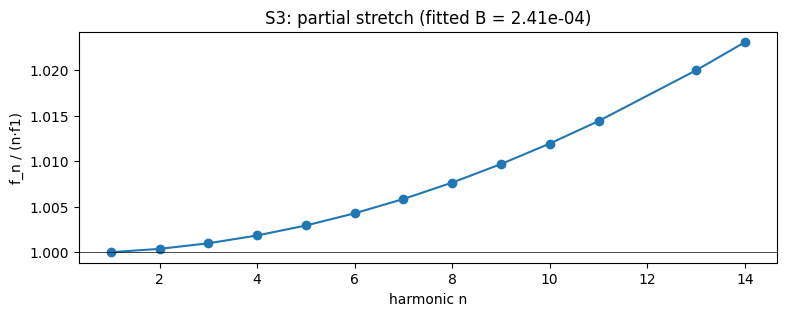

In [5]:
y_s3 = S.pluck_string(110.0, pluck_frac=0.15, fc=4500, gain=0.9990,
                      allpass=(-0.6, 40), dur_s=2.5)
f1, B, ns, fns = A.fit_inharmonicity(y_s3, 110.0)
print(f"f1 = {f1:.2f} Hz;   fitted inharmonicity B = {B:.2e} (piano range ≈ 1e-4 … 1e-2)")
print("n    f_n (Hz)   stretch f_n/(n·f1)")
for n, fn in zip(ns, fns):
    print(f"{n:2d}  {fn:9.2f}     {fn/(n*f1):8.4f}")
mono = np.all(np.diff(fns / (ns * f1)) > -1e-3)
print("stretch grows with n → dispersion CONFIRMED"
      if mono and fns[-1] / (ns[-1] * f1) > 1.005 else "WARNING: no clear stretch")

plt.figure(figsize=(9, 3)); plt.plot(ns, fns / (ns * f1), 'o-')
plt.axhline(1.0, color='k', lw=0.5)
plt.title(f"S3: partial stretch (fitted B = {B:.2e})")
plt.xlabel("harmonic n"); plt.ylabel("f_n / (n·f1)"); plt.show()
display(Audio(y_s3, rate=int(FS)))

## S4 — The bowed string

The self-oscillating string — the exact analogue of the reed (M4), and the other canonical MSW (1983) example: a **nonlinear element** (bow–string friction) coupled to a **linear resonator** (the string) in a feedback loop.

**Nonlinearity.** Rosin friction is strong when bow and string stick ($\mu_s$) and weak once sliding ($\mu_d<\mu_s$), falling with slip speed — a *negative resistance* around the sticking point that pumps the oscillation, exactly like the reed's falling flow-vs-pressure curve.

**Structure & junction.** The bow at $\beta$ splits the string into two segments, each collapsing to one loop ($r=-1$ far end). Velocity waves, $2Z_0$ seen by the bow:

$$v=v_h+\tfrac{F}{2Z_0},\quad \text{out}_\text{L}=v_{\text{in,R}}+\tfrac{F}{2Z_0},\ \ \text{out}_\text{R}=v_{\text{in,L}}+\tfrac{F}{2Z_0}.$$

Each sample solves $F$ and $v$ **simultaneously** (`_solve_slip`): try stick, else a quadratic in $\Delta v$ from the load-line/friction-curve intersection.

**Honest limitations:** the ambiguous double-crossing region is resolved by continuity with the previous sample (crude hysteresis); torsional waves and bow-hair compliance are ignored.

**What must *emerge*:** Helmholtz motion — one stick + one short slip per period, sawtooth at the bridge, period = the *full* string round trip, sticking fraction $\approx1-\beta$.

*Gate:* $f_0$ = full round trip, 1 slip/period, sticking $\approx1-\beta$, full series. The **force sweep** is the playability check (bowed analogue of the reed's lock-in range).

string round-trip f0 = 196.88 Hz   measured = 196.00 Hz
bow at β = 0.125; sticking fraction = 0.86 (Helmholtz ≈ 1−β = 0.88);  slips/period = 1.00 (Helmholtz = 1)
bow-force sweep (playability):
  F_b = 0.3:  stick = 0.68   slips/period = 3.27   (multiple-slip)
  F_b = 0.6:  stick = 0.73   slips/period = 2.99   (multiple-slip)
  F_b = 1.2:  stick = 0.86   slips/period = 1.00   ← Helmholtz
harmonics present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] …  (full series — Helmholtz sawtooth)


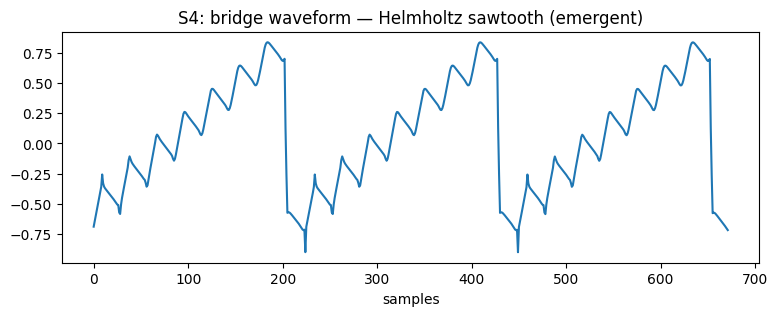

In [6]:
y_s4, stick = S.bow_string(196.0, beta=1/8, F_b=1.20, return_stick=True)
tail, st_tail = y_s4[int(0.5 * FS):], stick[int(0.5 * FS):]
f_meas = A.estimate_f0(tail)
half = int((FS / 196.0) // 2); beta = max(4, round((1/8) * half)) / half
spp = np.sum(st_tail[1:] < st_tail[:-1]) / (len(st_tail) * f_meas / FS)
print(f"string round-trip f0 = {FS/(2*half):.2f} Hz   measured = {f_meas:.2f} Hz")
print(f"bow at β = {beta:.3f}; sticking fraction = {st_tail.mean():.2f} "
      f"(Helmholtz ≈ 1−β = {1-beta:.2f});  slips/period = {spp:.2f} (Helmholtz = 1)")

print("bow-force sweep (playability):")
for Fb in (0.3, 0.6, 1.2):
    _, sflags = S.bow_string(196.0, beta=1/8, F_b=Fb, dur_s=1.0, return_stick=True)
    tl = sflags[int(0.4 * FS):]
    s = np.sum(tl[1:] < tl[:-1]) / (len(tl) * 196.0 / FS)
    print(f"  F_b = {Fb:3.1f}:  stick = {tl.mean():.2f}   slips/period = {s:.2f}"
          + ("   ← Helmholtz" if abs(s - 1) < 0.15 else "   (multiple-slip)"))

pf, _ = A.partials(tail, f_meas, fmax=15 * f_meas)
n_found = sorted({int(round(f / f_meas)) for f in pf if f / f_meas > 0.5})
print(f"harmonics present: {n_found[:12]} …  (full series — Helmholtz sawtooth)")

per = int(FS / f_meas); t0 = int(1.0 * FS)
plt.figure(figsize=(9, 3)); plt.plot(y_s4[t0:t0 + 3 * per])
plt.title("S4: bridge waveform — Helmholtz sawtooth (emergent)")
plt.xlabel("samples"); plt.show()
display(Audio(norm(y_s4), rate=int(FS)))

## S5 — Bridge + body: commuted synthesis

**The biggest structural difference from wind.** In wind the resonator *is* the radiator (the bell, M5). A string radiates almost nothing itself — too thin to push air. The **body** radiates, driven through the bridge, and unlike the string's neat harmonic series it has dozens of *irregular* resonances. That fixed, formant-like coloration is most of an instrument's identity — a Stradivarius is a body.

**Commuted synthesis.** String and body are both ≈linear and time-invariant, so convolution order commutes:

$$(\text{pluck}*\text{string})*\text{body}\equiv(\text{pluck}*\text{body})*\text{string}.$$

Fold the body IR into the *excitation* once — full body realism at zero per-sample body cost. Only exact for linear excitations; a **bow is nonlinear and breaks commutation**.

**Honest limitation:** `make_body_ir()` is synthetic — swap in a *measured* body IR for instant realism.

*Gate:* pitch must not move when the body is added; body modes fill the *inter*-harmonic floor.

string alone f0 = 196.13 Hz;  with body = 196.20 Hz  (pitch must not move)
body modes fill the inter-harmonic floor, 80–300 Hz, by 48.0 dB — the 'box'


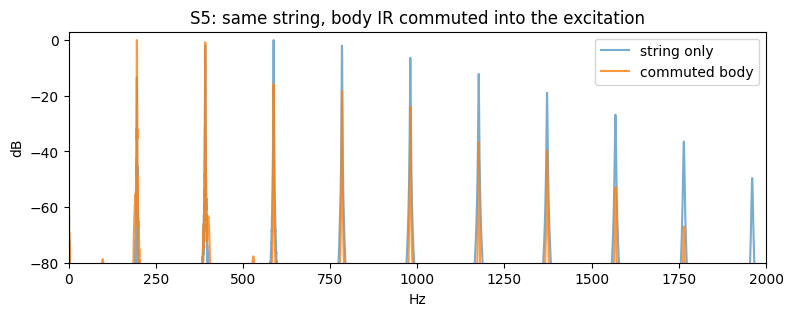

string only:


with body (commuted):


In [7]:
body = S.make_body_ir()
exc = S.pluck_excitation()
y_plain = S.string_loop(exc, 196.0)
y_body = S.string_loop(A.fftconvolve(exc, body), 196.0)
print(f"string alone f0 = {A.estimate_f0(y_plain):.2f} Hz;  "
      f"with body = {A.estimate_f0(y_body):.2f} Hz  (pitch must not move)")
fa, da = A.spectrum_db(y_plain); fb, dbb = A.spectrum_db(y_body)
lift = np.median(dbb[(fb > 80) & (fb < 300)]) - np.median(da[(fa > 80) & (fa < 300)])
print(f"body modes fill the inter-harmonic floor, 80–300 Hz, by {lift:.1f} dB — the 'box'")

plt.figure(figsize=(9, 3))
plt.plot(fa, da, alpha=0.6, label="string only")
plt.plot(fb, dbb, alpha=0.8, label="commuted body")
plt.xlim(0, 2000); plt.ylim(-80, 3); plt.legend()
plt.title("S5: same string, body IR commuted into the excitation")
plt.xlabel("Hz"); plt.ylabel("dB"); plt.show()
print("string only:"); display(Audio(norm(y_plain), rate=int(FS)))
print("with body (commuted):"); display(Audio(norm(y_body), rate=int(FS)))

## S6 — Realism: two polarizations + a coupled unison pair

A real string vibrates in **two transverse planes**. The bridge is stiffer vertically than horizontally, so the polarizations detune slightly (slow beating) and lose energy at very different rates (vertical fast, horizontal lingering) — giving the famous **two-stage decay**: fast attack-decay, then a long quiet *aftersound*. Piano doubles down: 2–3 unison strings per note, deliberately detuned, exchanging energy through the shared bridge.

**Honest limitation:** real coupling is via the bridge's shared mechanical impedance; the $\varepsilon$ cross-feed in `coupled_pair` is a phenomenological stand-in.

*Gate:* early decay slope ≫ late slope (the knee); unison beat rate ≈ the detuning in Hz.

two-stage decay:  early slope  -21.5 dB/s   late slope   -0.8 dB/s  (|early| >> |late| = aftersound)
unison pair detuned 0.15% → beating ≈ 0.33 Hz (slow shimmer)


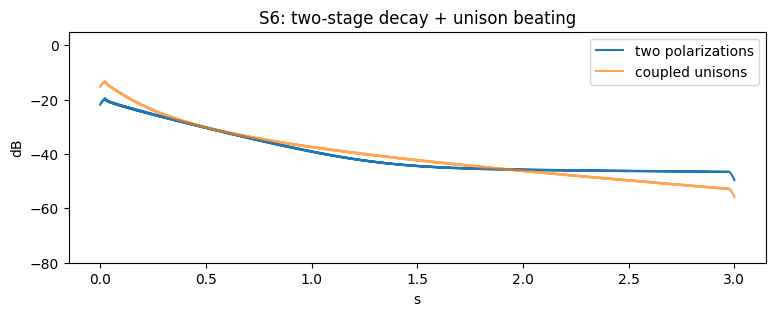

two polarizations:


coupled unisons:


In [8]:
y_pol = S.two_polarizations(220.0)
y_uni = S.coupled_pair(220.0, 220.0 * 1.0015, 0.9975, 0.9975, eps=0.02)
e = A.envelope_db(y_pol)
s_early = (e[int(0.35*FS)] - e[int(0.05*FS)]) / 0.3
s_late = (e[int(2.9*FS)] - e[int(2.0*FS)]) / 0.9
print(f"two-stage decay:  early slope {s_early:6.1f} dB/s   late slope {s_late:6.1f} dB/s  "
      f"(|early| >> |late| = aftersound)")
print(f"unison pair detuned 0.15% → beating ≈ {220.0*0.0015:.2f} Hz (slow shimmer)")

plt.figure(figsize=(9, 3))
plt.plot(np.arange(len(y_pol)) / FS, e, label="two polarizations")
plt.plot(np.arange(len(y_uni)) / FS, A.envelope_db(y_uni), alpha=0.7, label="coupled unisons")
plt.ylim(-80, 5); plt.legend(); plt.xlabel("s"); plt.ylabel("dB")
plt.title("S6: two-stage decay + unison beating"); plt.show()
print("two polarizations:"); display(Audio(norm(y_pol), rate=int(FS)))
print("coupled unisons:"); display(Audio(norm(y_uni), rate=int(FS)))

## S7 — The piano hammer

A **third excitation class**: not an initial condition (pluck), not a sustained feedback loop (bow), but a *transient nonlinear contact*. The felt hammer is a stiffening spring on a free-flying mass:

$$F=K\,c^{\,p}\ (c=y_\text{hammer}-y_\text{string}>0),\qquad m\dot v_h=-F,\qquad p\approx2\text{–}3.$$

**Why velocity controls brightness** (emergent): hit harder → deeper compression → stiffer $c^p$ spring → higher contact resonance → **shorter contact** → wider spectrum. Fortissimo is brighter, not just louder — nobody programs a brightness knob; it falls out of $p>1$.

**Honest limitations:** elastic felt (real felt is hysteretic — Stulov); soundboard loading of the bridge ignored (S5's job).

*Gate:* pitch identical at both dynamics; harder strike → shorter contact and higher spectral centroid.

pitch: soft 109.93 Hz / hard 109.95 Hz (must match — dynamics ≠ tuning)
contact time:   soft   3.83 ms    hard   3.29 ms   (harder → shorter)
spectral centroid:   soft 315 Hz    hard 398 Hz   (harder → brighter)
velocity→brightness emerges from p > 1: CONFIRMED


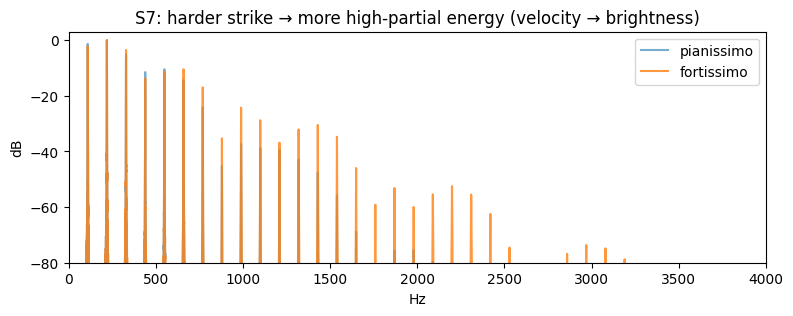

pianissimo:


fortissimo:


In [9]:
y_soft, c_soft = S.hammer_strike(v0=0.002)
y_hard, c_hard = S.hammer_strike(v0=0.012)
print(f"pitch: soft {A.estimate_f0(y_soft):.2f} Hz / hard {A.estimate_f0(y_hard):.2f} Hz "
      f"(must match — dynamics ≠ tuning)")
print(f"contact time:   soft {1000*c_soft/FS:6.2f} ms    hard {1000*c_hard/FS:6.2f} ms   (harder → shorter)")
cs, ch = A.centroid(norm(y_soft)), A.centroid(norm(y_hard))
print(f"spectral centroid:   soft {cs:.0f} Hz    hard {ch:.0f} Hz   (harder → brighter)")
print("velocity→brightness emerges from p > 1: "
      + ("CONFIRMED" if (c_hard < c_soft and ch > cs) else "check K/m/p"))

plt.figure(figsize=(9, 3))
fs_, ds_ = A.spectrum_db(norm(y_soft)); fh_, dh_ = A.spectrum_db(norm(y_hard))
plt.plot(fs_, ds_, alpha=0.6, label="pianissimo"); plt.plot(fh_, dh_, alpha=0.8, label="fortissimo")
plt.xlim(0, 4000); plt.ylim(-80, 3); plt.legend()
plt.title("S7: harder strike → more high-partial energy (velocity → brightness)")
plt.xlabel("Hz"); plt.ylabel("dB"); plt.show()
print("pianissimo:"); display(Audio(norm(y_soft), rate=int(FS)))
print("fortissimo:"); display(Audio(norm(y_hard), rate=int(FS)))

## String track status

| # | Milestone | Status |
|---|-----------|--------|
| S0 | Karplus–Strong baseline | ✅ (was wind M0) |
| S1 | Fixed–fixed waveguide + pluck | ✅ all harmonics, L/5 comb |
| S2 | Frequency-dependent loss | ✅ HF dies first |
| S3 | Stiffness → inharmonicity | ✅ all-pass dispersion, $B$ fitted |
| S4 | Bowed string (MSW stick–slip) | ✅ Helmholtz emergent |
| S5 | Bridge + body (commuted) | ✅ synthetic IR — swap for measured |
| S6 | Polarizations + unisons | ✅ two-stage decay, beating |
| S7 | Hammer (nonlinear felt) | ✅ velocity→brightness emergent |

**Files:** `string_analysis.py` (analysis engine) · `string_synth.py` (synthesis engine) · `render_assets.py` (WAV/figure I/O) · this notebook.

**Open honest items:** exact-$B$ all-pass design (S3); bow torsion / hair compliance and proper hysteresis handling (S4); measured body IR + true bridge-impedance coupling (S5/S6); Stulov hysteretic felt (S7).

**Natural next steps:** the **percussion** track (2-D membranes — where 1-D waveguides give way to waveguide meshes / modal synthesis), or the **Rust/WASM port** of the now-complete wind + brass + string engines.